# EDA: Fake and Real News Dataset

This notebook walks through **Exploratory Data Analysis (EDA)** of the [Fake and Real News Dataset](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset) from Kaggle. The goal is to build a clear understanding of the data before modeling.

---

### What you will learn

1. **Load & inspect** — Where the data comes from and how it is structured.
2. **Data quality** — Missing values, duplicates, and empty or invalid rows.
3. **Column meanings** — What each column represents (title, text, subject, date, label).
4. **Target variable** — How many Fake vs Real articles (class balance).
5. **Univariate analysis** — Distributions of text length, word count, title length, etc.
6. **Bivariate analysis** — How features differ between Fake and Real news.
7. **Categorical & time** — Subject and date distributions.
8. **Text characteristics** — Top words, punctuation, vocabulary diversity.
9. **Summary** — Main takeaways and implications for modeling.

---

### Dataset source

- **Source:** Kaggle, downloaded via `kagglehub`.
- **Contents:** Two CSV files: `True.csv` (real news) and `Fake.csv` (fake news).
- **Task:** Binary classification — predict whether an article is **Fake (0)** or **Real (1)**.

In [74]:
import os
import re
from collections import Counter

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# default plot size + style
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

## Step 1 — Load dataset from Kaggle

We use `kagglehub` to download the dataset (no Kaggle API key required for this public dataset). The dataset contains two files: **True.csv** (real news) and **Fake.csv** (fake news). We merge them into one dataframe and add a **label** column: `1` = Real, `0` = Fake. We also create a combined **text** column (title + body) for later analysis and modeling.

In [75]:
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
print("Dataset path:", path)
print(os.listdir(path))

Dataset path: /Users/abubaker/.cache/kagglehub/datasets/clmentbisaillon/fake-and-real-news-dataset/versions/1
['Fake.csv', 'True.csv']


**What we did:** Loaded `True.csv` and `Fake.csv`, assigned labels, and combined title + body into a single `text` column. The table above shows the first 10 rows (all from Real news because True.csv is loaded first).

In [76]:
true_path = os.path.join(path, "True.csv")
fake_path = os.path.join(path, "Fake.csv")

df_true = pd.read_csv(true_path)
df_fake = pd.read_csv(fake_path)

# real=1, fake=0
df_true["label"] = 1
df_fake["label"] = 0

df = pd.concat([df_true, df_fake], ignore_index=True)
# combine title + body so we have one text field for analysis
df["text"] = df["title"].fillna("") + " " + df["text"].fillna("")

df.head(10)

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...","As U.S. budget fight looms, Republicans flip t...",politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,U.S. military to accept transgender recruits o...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,Senior U.S. Republican senator: 'Let Mr. Muell...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,FBI Russia probe helped by Australian diplomat...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,Trump wants Postal Service to charge 'much mor...,politicsNews,"December 29, 2017",1
5,"White House, Congress prepare for talks on spe...","White House, Congress prepare for talks on spe...",politicsNews,"December 29, 2017",1
6,"Trump says Russia probe will be fair, but time...","Trump says Russia probe will be fair, but time...",politicsNews,"December 29, 2017",1
7,Factbox: Trump on Twitter (Dec 29) - Approval ...,Factbox: Trump on Twitter (Dec 29) - Approval ...,politicsNews,"December 29, 2017",1
8,Trump on Twitter (Dec 28) - Global Warming,Trump on Twitter (Dec 28) - Global Warming The...,politicsNews,"December 29, 2017",1
9,Alabama official to certify Senator-elect Jone...,Alabama official to certify Senator-elect Jone...,politicsNews,"December 28, 2017",1


## Step 2 — Basic dataset info

Check the **shape** (number of rows and columns), **column names**, and **data types**. This tells us how much data we have and what kind of values each column holds (text vs numeric, etc.).

In [77]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
df.dtypes

Shape: (44898, 5)

Columns: ['title', 'text', 'subject', 'date', 'label']

Data types:


title      object
text       object
subject    object
date       object
label       int64
dtype: object

### Column definitions

| Column   | Description |
|----------|-------------|
| **title**  | Headline of the article. |
| **text**   | Full article body (in the original CSVs). Here we use **title + " " + text** as the combined content for analysis. |
| **subject**| Topic/category (e.g. politicsNews, world news). |
| **date**   | Publication date (string format). |
| **label**  | **0** = Fake news, **1** = Real news. This is our target variable for classification. |

## Step 3 — Data quality checks

Before analyzing distributions, we check for **missing values**, **duplicate rows**, and **empty or very short texts**. These can affect model training and metrics.

In [78]:
print("=== Missing values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values.")
print()

print("=== Duplicates ===")
n_dup = df.duplicated().sum()
print(f"Full duplicate rows: {n_dup}")
n_dup_title = df.duplicated(subset=["title"]).sum()
print(f"Rows with duplicate title: {n_dup_title}")
print()

print("=== Text completeness ===")
empty_text = (df["text"].fillna("").str.strip().str.len() == 0).sum()
short_text = (df["text"].fillna("").str.split().str.len() < 5).sum()
print(f"Rows with empty text: {empty_text}")
print(f"Rows with fewer than 5 words: {short_text}")

=== Missing values ===
No missing values.

=== Duplicates ===
Full duplicate rows: 209
Rows with duplicate title: 6169

=== Text completeness ===
Rows with empty text: 0
Rows with fewer than 5 words: 11


In [79]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


,title,text,subject,date,label
count,44898,44898,44898,44898,44898.000000
unique,38729,39105,8,2397,NaN
top,Factbox: Trump fills top jobs for his administ...,Highlights: The Trump presidency on April 13 a...,politicsNews,"December 20, 2017",NaN
freq,14,8,11272,182,NaN
mean,NaN,NaN,NaN,NaN,0.477015
std,NaN,NaN,NaN,NaN,0.499477
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,1.000000


## Step 4 — Class distribution (Fake vs Real)

Understanding **class balance** is important: a 50/50 split is ideal for classification; strong imbalance may require resampling or different metrics (e.g. F1, precision/recall).

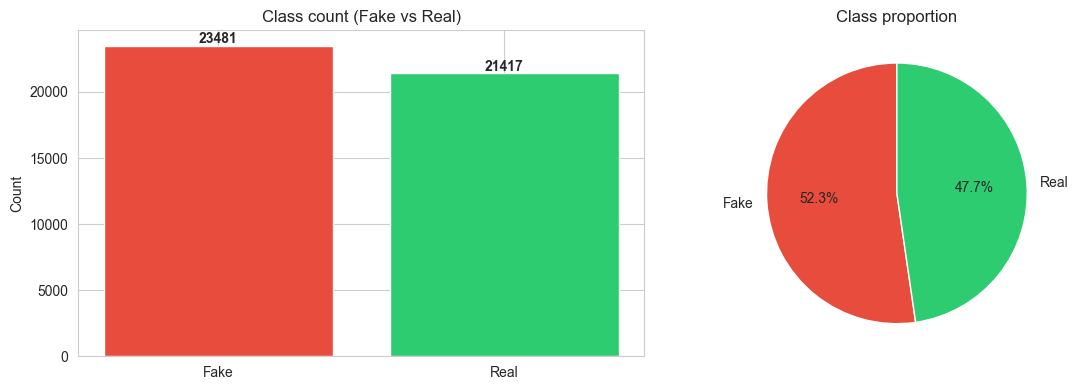

In [80]:
counts = df["label"].value_counts().sort_index()
labels = ["Fake", "Real"]
colors = ["#e74c3c", "#2ecc71"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, counts.values, color=colors)
axes[0].set_title("Class count (Fake vs Real)")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Class proportion")
plt.tight_layout()
plt.show()

## Step 5 — Text length & word count

We add **word_count** and **char_count** per article. Comparing distributions by class can reveal whether fake vs real articles tend to differ in length (e.g. sensational headlines may be shorter or longer).

/var/folders/7m/gn8zvv2542lbg7gxf41cqtmm0000gn/T/ipykernel_22741/2817257419.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Fake", "Real"])


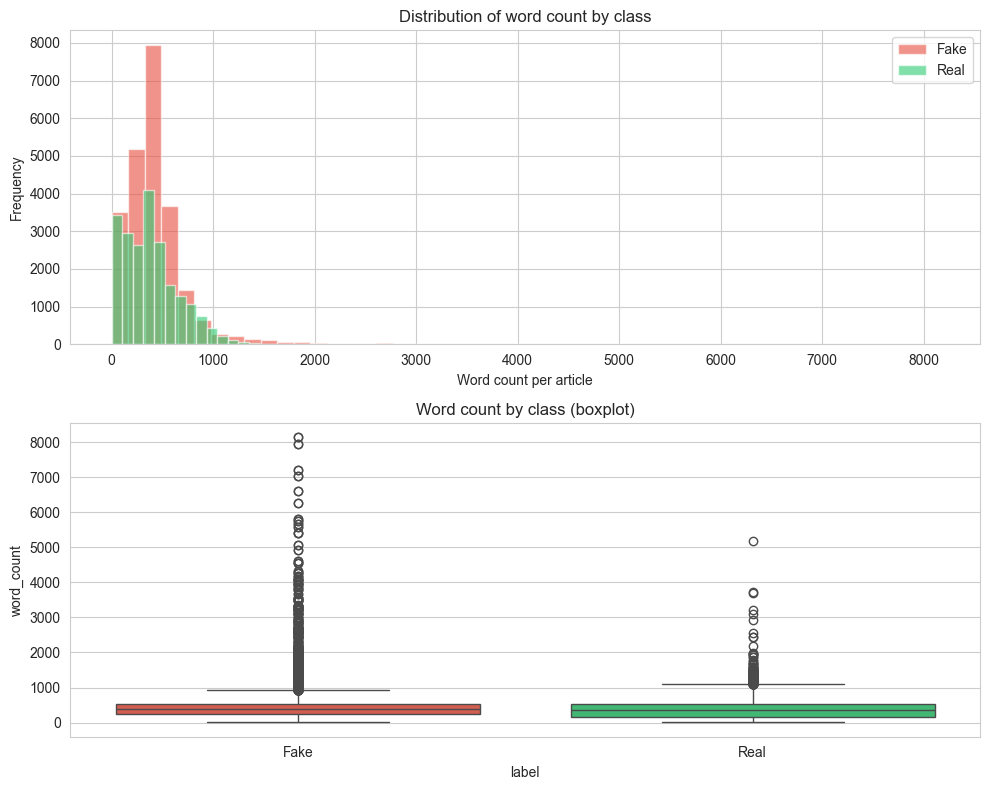

In [81]:
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for idx, label_val in enumerate([0, 1]):
    subset = df[df["label"] == label_val]["word_count"]
    axes[0].hist(subset, bins=50, alpha=0.6, label=["Fake", "Real"][label_val], color=colors[label_val])
axes[0].set_xlabel("Word count per article")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of word count by class")
axes[0].legend()

sns.boxplot(data=df, x="label", y="word_count", hue="label", order=[0, 1], hue_order=[0, 1], palette={0: colors[0], 1: colors[1]}, legend=False, ax=axes[1])
axes[1].set_xticklabels(["Fake", "Real"])
axes[1].set_title("Word count by class (boxplot)")
plt.tight_layout()
plt.show()

## Step 6 — Subject distribution (if available)

**Subject** is the topic/category of the article. Seeing how Fake and Real news are distributed across subjects helps understand whether certain topics are over-represented in one class.

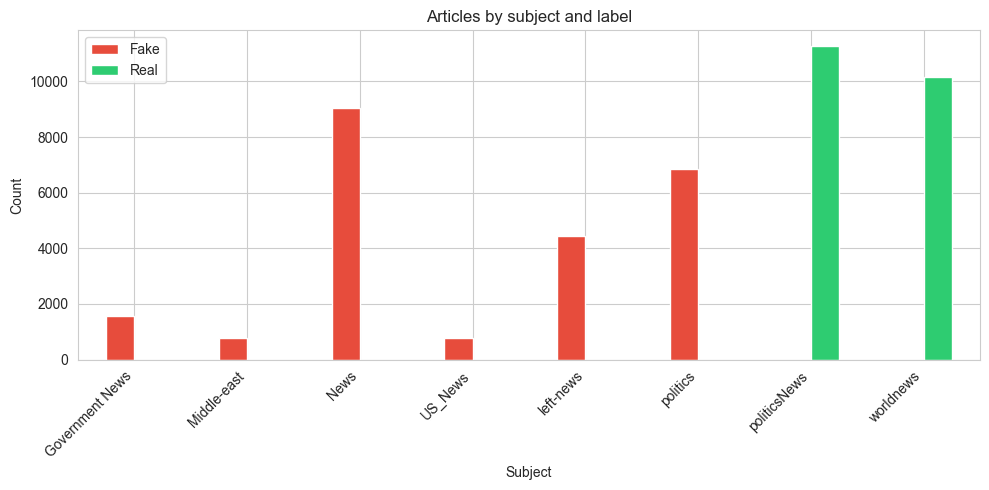

In [82]:
if "subject" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    subject_counts = df.groupby(["subject", "label"]).size().unstack(fill_value=0)
    subject_counts.columns = ["Fake", "Real"]
    subject_counts.plot(kind="bar", ax=ax, color=colors)
    ax.set_title("Articles by subject and label")
    ax.set_xlabel("Subject")
    ax.set_ylabel("Count")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No 'subject' column in this dataset.")

## Step 7 — Date distribution (if available)

**When** were articles published? Time trends can show whether fake or real news increased in certain periods (e.g. around elections) and help check for temporal bias in the dataset.

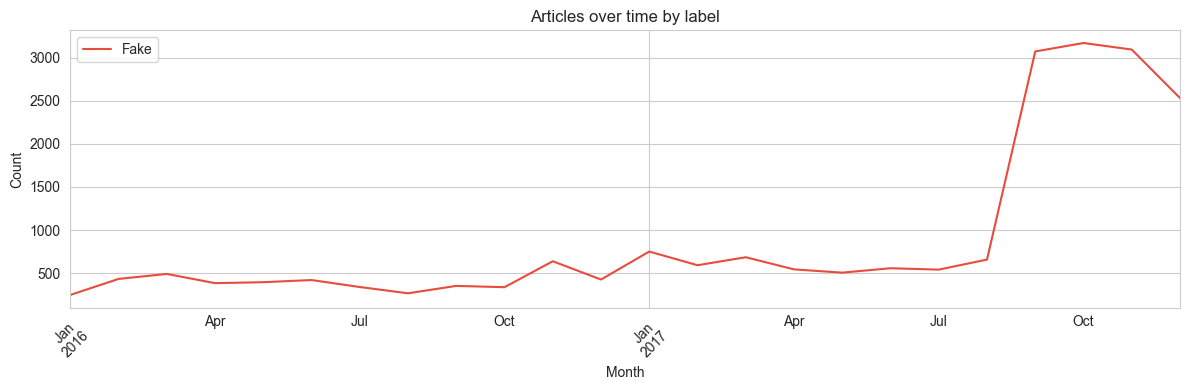

In [83]:
if "date" in df.columns:
    df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce")
    valid_dates = df["date_parsed"].dropna()
    if len(valid_dates) > 0:
        fig, ax = plt.subplots(figsize=(12, 4))
        df[df["date_parsed"].notna()].groupby([df["date_parsed"].dt.to_period("M"), "label"]).size().unstack(fill_value=0).plot(ax=ax, color=colors)
        ax.set_title("Articles over time by label")
        ax.set_xlabel("Month")
        ax.set_ylabel("Count")
        ax.legend(["Fake", "Real"])
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("Could not parse dates.")
else:
    print("No 'date' column in this dataset.")

## Step 8 — Missing values (visual)

A **visual** check for missing values. If any column has many nulls, we may need to drop or impute before modeling.

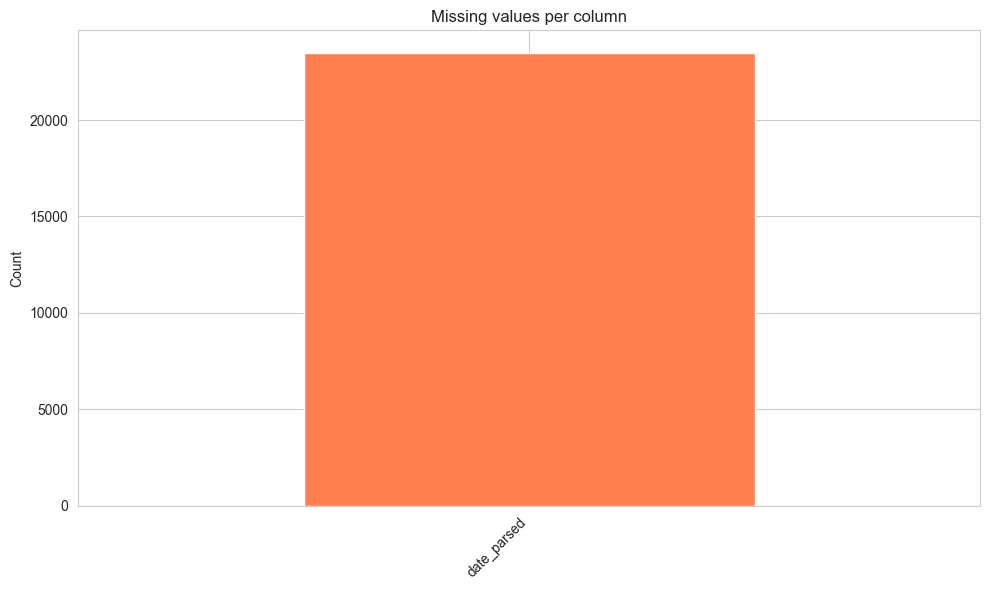

In [84]:
missing = df.isnull().sum()
if missing.any():
    missing[missing > 0].plot(kind="bar", color="coral")
    plt.title("Missing values per column")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values.")

## Step 9 — Top words by class (Fake vs Real)

**Most frequent words** in Fake vs Real articles. Differences in vocabulary can inform feature engineering and help interpret model behavior (e.g. which words drive predictions).

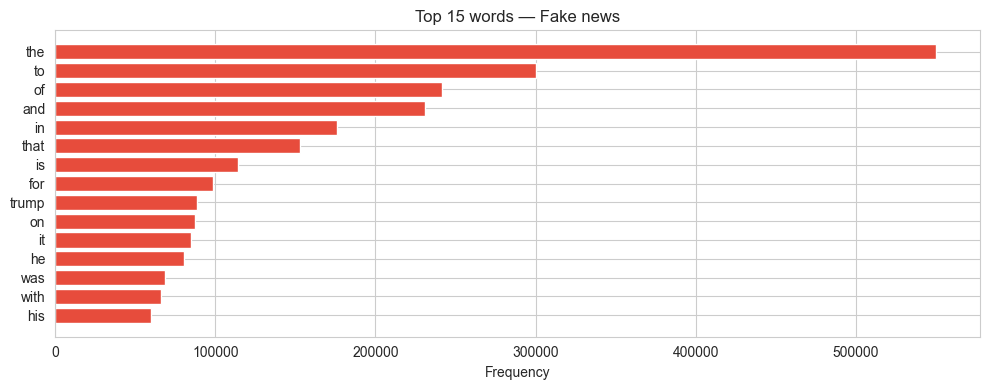

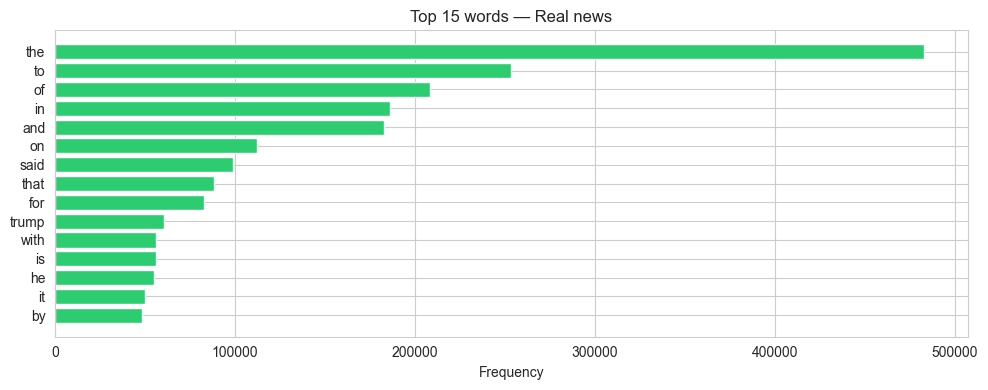

In [85]:
def tokenize(s):
    if not isinstance(s, str):
        return []
    # simple word tokenization (lowercase, 2+ chars)
    return re.findall(r"\b[a-z]{2,}\b", s.lower())

for label_val, name in [(0, "Fake"), (1, "Real")]:
    texts = " ".join(df[df["label"] == label_val]["text"].astype(str))
    counts = Counter(tokenize(texts)).most_common(15)
    words, freqs = zip(*counts)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(range(len(words)), freqs, color=colors[label_val])
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    ax.set_title(f"Top 15 words — {name} news")
    ax.set_xlabel("Frequency")
    plt.tight_layout()
    plt.show()

## Step 10 — Title length by class

**Headline length** (characters) by class. Fake news sometimes uses more sensational or longer/shorter headlines; this plot helps spot such patterns.

/var/folders/7m/gn8zvv2542lbg7gxf41cqtmm0000gn/T/ipykernel_22741/1036712266.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Fake", "Real"])


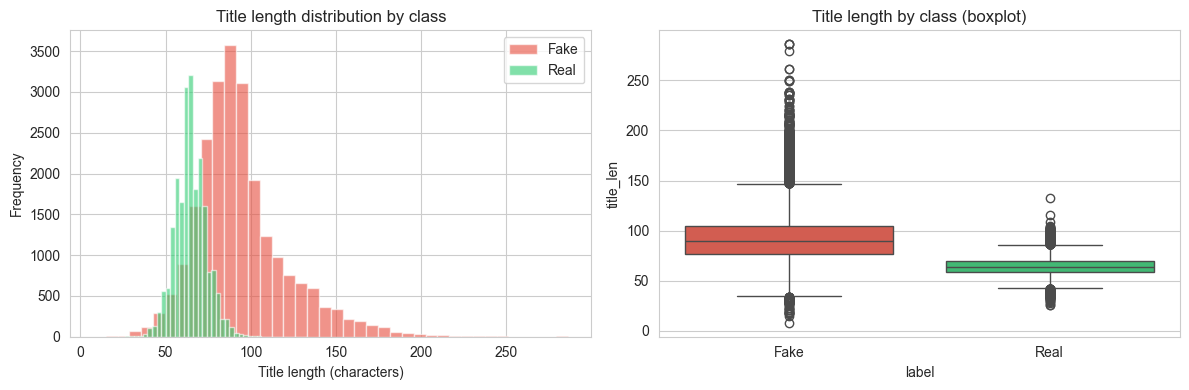

In [86]:
df["title_len"] = df["title"].fillna("").str.len()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for idx, label_val in enumerate([0, 1]):
    subset = df[df["label"] == label_val]["title_len"]
    axes[0].hist(subset, bins=40, alpha=0.6, label=["Fake", "Real"][label_val], color=colors[label_val])
axes[0].set_xlabel("Title length (characters)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Title length distribution by class")
axes[0].legend()
sns.boxplot(data=df, x="label", y="title_len", hue="label", order=[0, 1], hue_order=[0, 1], palette={0: colors[0], 1: colors[1]}, legend=False, ax=axes[1])
axes[1].set_xticklabels(["Fake", "Real"])
axes[1].set_title("Title length by class (boxplot)")
plt.tight_layout()
plt.show()

## Step 11 — Average word length by class

**Average word length** (characters per word) by class. Simpler language may use shorter words; more formal writing may use longer words.

/var/folders/7m/gn8zvv2542lbg7gxf41cqtmm0000gn/T/ipykernel_22741/232646710.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Fake", "Real"])


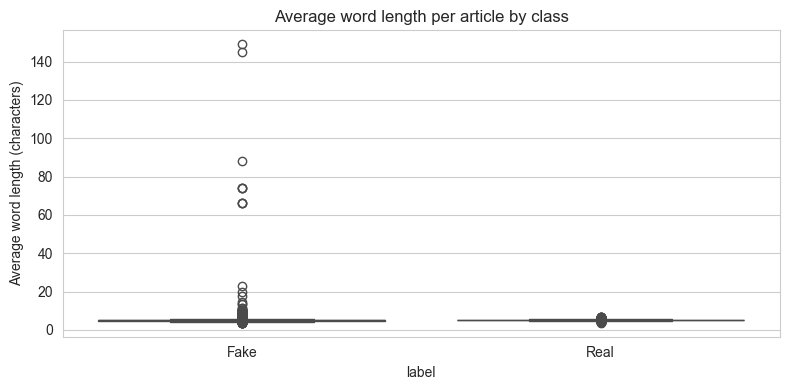

In [87]:
def avg_word_len(s):
    words = str(s).split()
    return np.mean([len(w) for w in words]) if words else 0
df["avg_word_len"] = df["text"].apply(avg_word_len)
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="label", y="avg_word_len", hue="label", order=[0, 1], hue_order=[0, 1], palette={0: colors[0], 1: colors[1]}, legend=False, ax=ax)
ax.set_xticklabels(["Fake", "Real"])
ax.set_ylabel("Average word length (characters)")
ax.set_title("Average word length per article by class")
plt.tight_layout()
plt.show()

## Step 12 — Subject × Label heatmap

**Heatmap** of article counts for each (subject, label) pair. Quickly shows which topics are more associated with Fake or Real news.

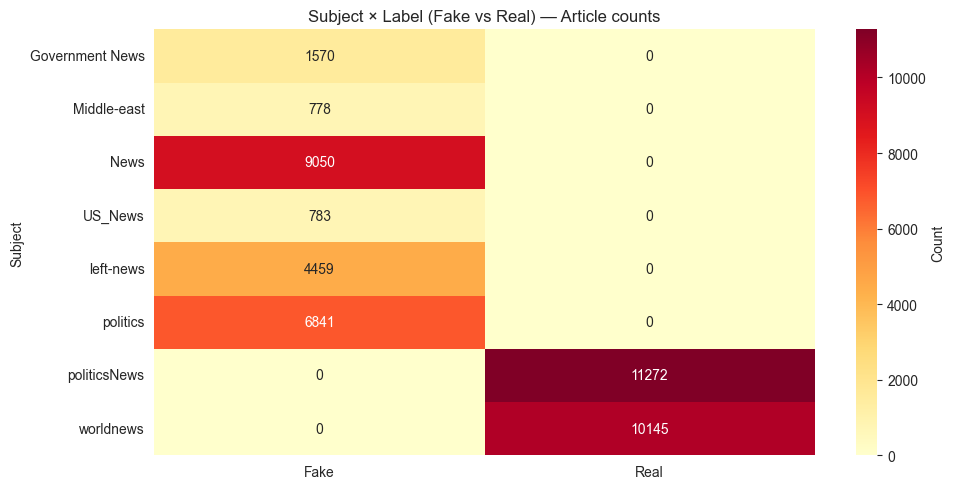

In [88]:
if "subject" in df.columns:
    cross = pd.crosstab(df["subject"], df["label"])
    cross.columns = ["Fake", "Real"]
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(cross, annot=True, fmt="d", cmap="YlOrRd", ax=ax, cbar_kws={"label": "Count"})
    ax.set_title("Subject × Label (Fake vs Real) — Article counts")
    ax.set_ylabel("Subject")
    plt.tight_layout()
    plt.show()
else:
    print("No 'subject' column.")

## Step 13 — Word count vs character count (scatter)

**Scatter plot** of word count vs character count (sampled), colored by class. Shows whether the two classes occupy different regions (e.g. different typical article lengths).

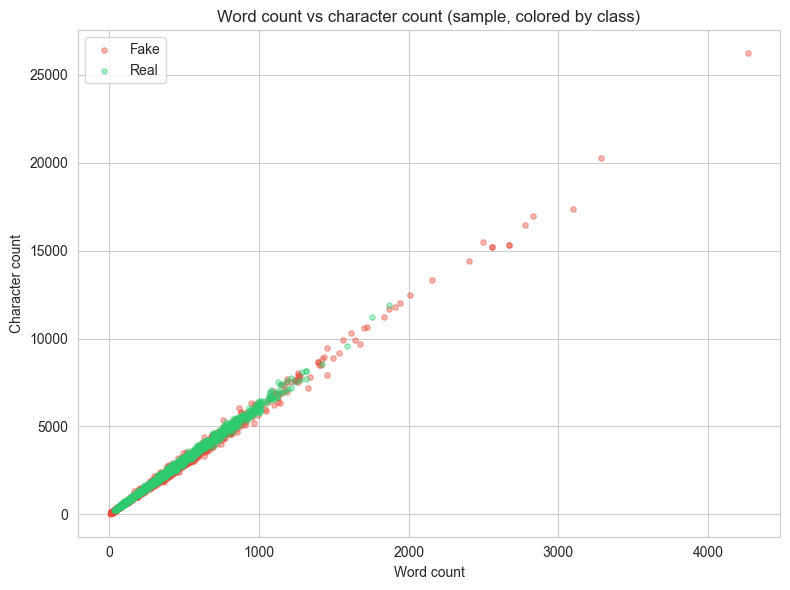

In [89]:
sample = df.sample(min(3000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 6))
for label_val, name in [(0, "Fake"), (1, "Real")]:
    sub = sample[sample["label"] == label_val]
    ax.scatter(sub["word_count"], sub["char_count"], alpha=0.4, s=15, label=name, color=colors[label_val])
ax.set_xlabel("Word count")
ax.set_ylabel("Character count")
ax.set_title("Word count vs character count (sample, colored by class)")
ax.legend()
plt.tight_layout()
plt.show()

## Step 14 — Articles by day of week (if date available)

**Day-of-week** distribution by label. Helps spot if fake or real news is more common on certain days (e.g. weekdays vs weekends).

/var/folders/7m/gn8zvv2542lbg7gxf41cqtmm0000gn/T/ipykernel_22741/2858168133.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct = dow.groupby(["day_of_week", "label"]).size().unstack(fill_value=0)


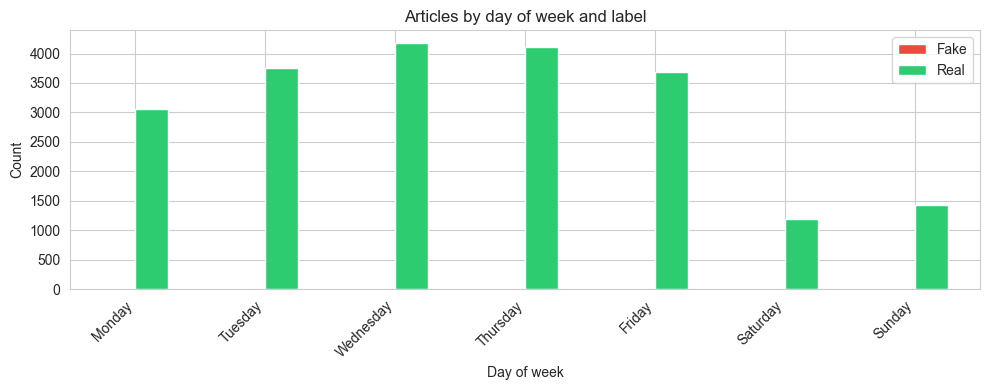

In [90]:
if "date" in df.columns:
    df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce")
    dow = df[df["date_parsed"].notna()].copy()
    if len(dow) > 0:
        dow["day_of_week"] = dow["date_parsed"].dt.day_name()
        order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
        dow["day_of_week"] = pd.Categorical(dow["day_of_week"], categories=order, ordered=True)
        ct = dow.groupby(["day_of_week", "label"]).size().unstack(fill_value=0)
        ct = ct.reindex(columns=[0, 1], fill_value=0)
        ct.columns = ["Fake", "Real"]
        ct.plot(kind="bar", figsize=(10, 4), color=colors)
        plt.title("Articles by day of week and label")
        plt.xlabel("Day of week")
        plt.ylabel("Count")
        plt.legend()
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("No valid dates to plot.")
else:
    print("No 'date' column.")

## Step 15 — Unique words per article (vocabulary diversity)

**Vocabulary size** (number of unique words per article) by class. Higher diversity may indicate more varied or formal writing; lower may indicate repetitive or template-like text.

/var/folders/7m/gn8zvv2542lbg7gxf41cqtmm0000gn/T/ipykernel_22741/1646205787.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Fake", "Real"])


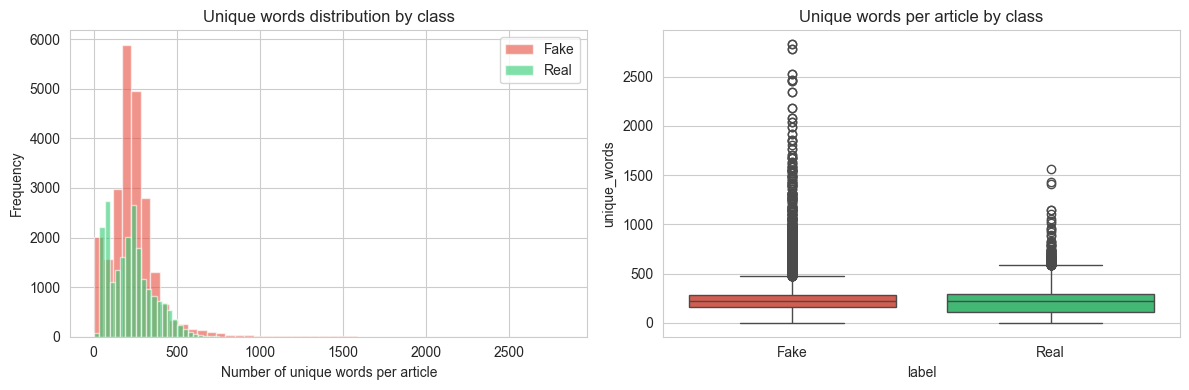

In [91]:
df["unique_words"] = df["text"].str.lower().str.split().apply(lambda x: len(set(x)) if isinstance(x, list) else 0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for idx, label_val in enumerate([0, 1]):
    subset = df[df["label"] == label_val]["unique_words"]
    axes[0].hist(subset, bins=50, alpha=0.6, label=["Fake", "Real"][label_val], color=colors[label_val])
axes[0].set_xlabel("Number of unique words per article")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Unique words distribution by class")
axes[0].legend()
sns.boxplot(data=df, x="label", y="unique_words", hue="label", order=[0, 1], hue_order=[0, 1], palette={0: colors[0], 1: colors[1]}, legend=False, ax=axes[1])
axes[1].set_xticklabels(["Fake", "Real"])
axes[1].set_title("Unique words per article by class")
plt.tight_layout()
plt.show()

## Step 16 — Punctuation & special character usage by class

**Exclamation marks**, **question marks**, and **uppercase ratio** by class. Sensational or clickbait content often uses more exclamations and caps; this helps test that hypothesis.

/var/folders/7m/gn8zvv2542lbg7gxf41cqtmm0000gn/T/ipykernel_22741/401397046.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Fake", "Real"])
/var/folders/7m/gn8zvv2542lbg7gxf41cqtmm0000gn/T/ipykernel_22741/401397046.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Fake", "Real"])
/var/folders/7m/gn8zvv2542lbg7gxf41cqtmm0000gn/T/ipykernel_22741/401397046.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(["Fake", "Real"])


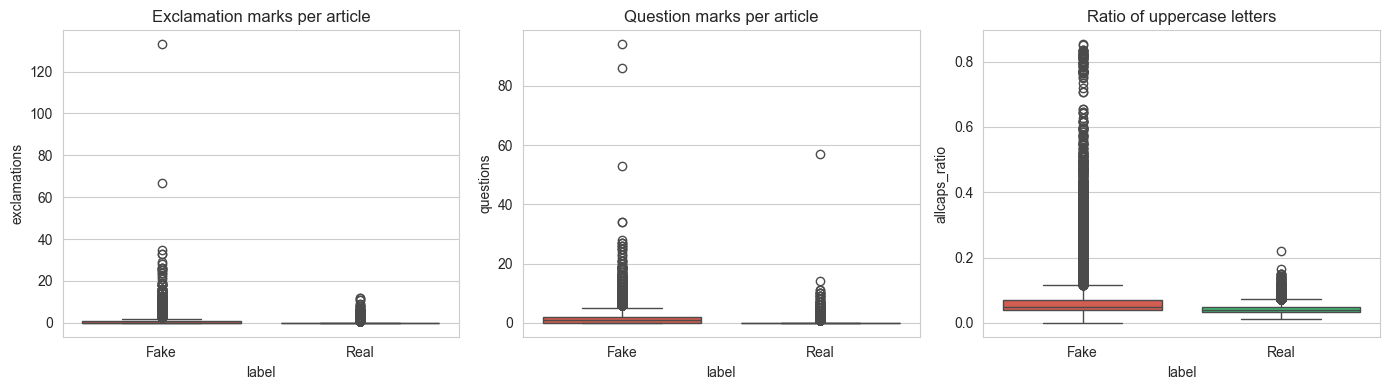

In [92]:
df["exclamations"] = df["text"].str.count(r"!").fillna(0)
df["questions"] = df["text"].str.count(r"\?").fillna(0)
df["allcaps_ratio"] = df["text"].apply(lambda s: sum(1 for c in str(s) if c.isupper()) / max(len(str(s)), 1))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(data=df, x="label", y="exclamations", hue="label", order=[0, 1], hue_order=[0, 1], palette={0: colors[0], 1: colors[1]}, legend=False, ax=axes[0])
axes[0].set_xticklabels(["Fake", "Real"])
axes[0].set_title("Exclamation marks per article")
sns.boxplot(data=df, x="label", y="questions", hue="label", order=[0, 1], hue_order=[0, 1], palette={0: colors[0], 1: colors[1]}, legend=False, ax=axes[1])
axes[1].set_xticklabels(["Fake", "Real"])
axes[1].set_title("Question marks per article")
sns.boxplot(data=df, x="label", y="allcaps_ratio", hue="label", order=[0, 1], hue_order=[0, 1], palette={0: colors[0], 1: colors[1]}, legend=False, ax=axes[2])
axes[2].set_xticklabels(["Fake", "Real"])
axes[2].set_title("Ratio of uppercase letters")
plt.tight_layout()
plt.show()

## Step 17 — Subject proportion within each class (stacked)

**Stacked bar** showing the **mix of subjects** within Fake vs Real. Answers: “Among fake articles, what % are politics? world news? etc.” and the same for real.

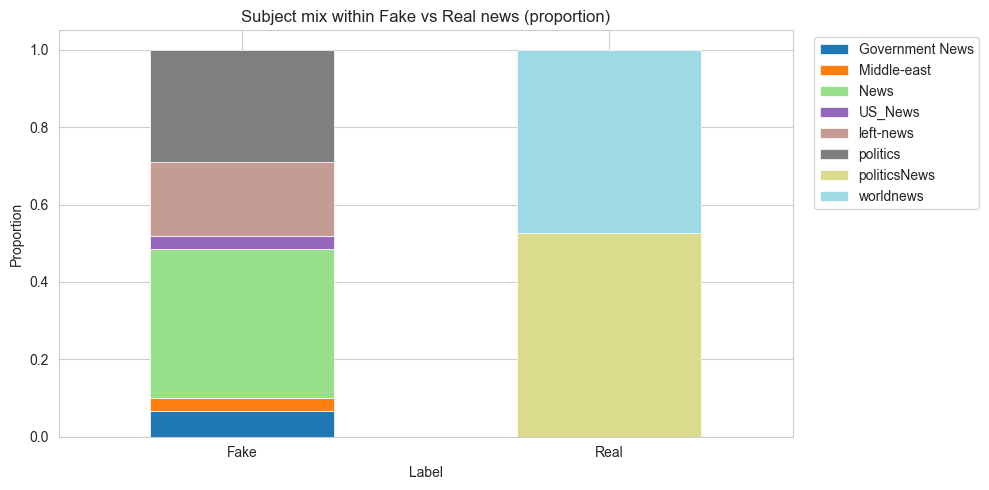

In [93]:
if "subject" in df.columns:
    prop = df.groupby("label")["subject"].value_counts(normalize=True).unstack(fill_value=0)
    prop.index = ["Fake", "Real"]
    prop.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="tab20", edgecolor="white", linewidth=0.5)
    plt.title("Subject mix within Fake vs Real news (proportion)")
    plt.xlabel("Label")
    plt.ylabel("Proportion")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No 'subject' column.")

## Step 18 — Numeric features correlation (by class)

**Correlation matrices** of derived numeric features (word count, char count, title length, etc.) **separately for Fake and Real**. Helps see which features move together and whether patterns differ by class.

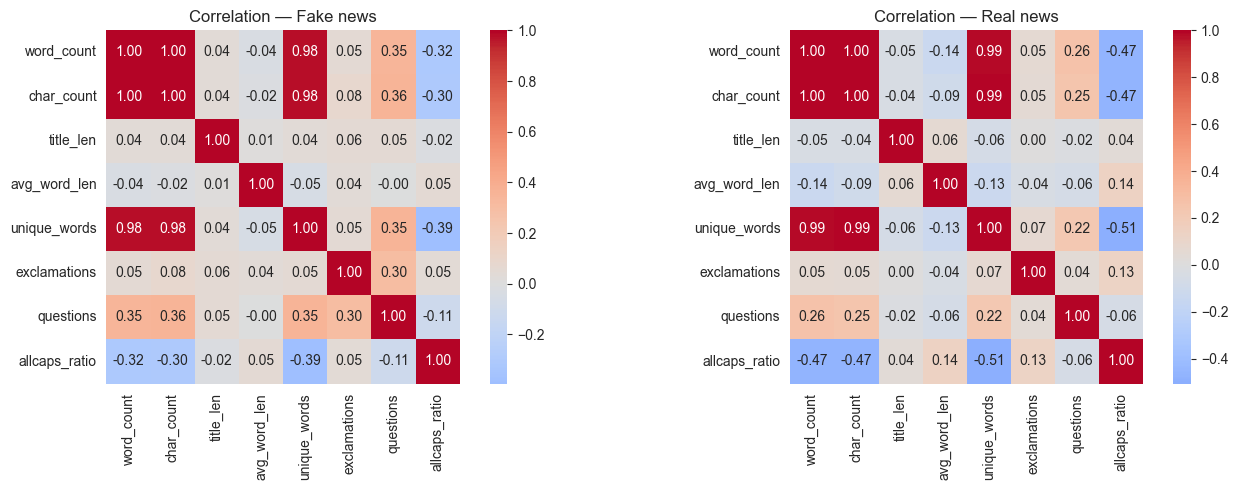

In [94]:
num_cols = ["word_count", "char_count", "title_len", "avg_word_len", "unique_words", "exclamations", "questions", "allcaps_ratio"]
num_cols = [c for c in num_cols if c in df.columns]
if len(num_cols) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (label_val, name) in zip(axes, [(0, "Fake"), (1, "Real")]):
        sub = df[df["label"] == label_val][num_cols]
        sns.heatmap(sub.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
        ax.set_title(f"Correlation — {name} news")
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 2 numeric columns from: word_count, char_count, title_len, avg_word_len, unique_words, exclamations, questions, allcaps_ratio")

## Step 19 — Sample headlines (Fake vs Real)

**Qualitative check**: read a few **example headlines** from each class to build intuition and spot wording patterns (e.g. sensationalism, source style).

In [95]:
if "title" in df.columns:
    print("=== Sample FAKE headlines ===")
    for t in df[df["label"] == 0]["title"].dropna().head(5).tolist():
        print("-", t[:100] + ("..." if len(str(t)) > 100 else ""))
    print("\n=== Sample REAL headlines ===")
    for t in df[df["label"] == 1]["title"].dropna().head(5).tolist():
        print("-", t[:100] + ("..." if len(str(t)) > 100 else ""))
else:
    print("No 'title' column; showing first 100 chars of 'text'.")
    for label, name in [(0, "Fake"), (1, "Real")]:
        print(f"=== Sample {name} ===")
        for t in df[df["label"] == label]["text"].head(3).tolist():
            print("-", str(t)[:100] + "...")
        print()

=== Sample FAKE headlines ===
-  Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing
-  Drunk Bragging Trump Staffer Started Russian Collusion Investigation
-  Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’
-  Trump Is So Obsessed He Even Has Obama’s Name Coded Into His Website (IMAGES)
-  Pope Francis Just Called Out Donald Trump During His Christmas Speech

=== Sample REAL headlines ===
- As U.S. budget fight looms, Republicans flip their fiscal script
- U.S. military to accept transgender recruits on Monday: Pentagon
- Senior U.S. Republican senator: 'Let Mr. Mueller do his job'
- FBI Russia probe helped by Australian diplomat tip-off: NYT
- Trump wants Postal Service to charge 'much more' for Amazon shipments


---

# Summary & key takeaways

Use this section to capture what you learned from the EDA and how it should inform modeling and evaluation.

### Data overview
- **Size:** Check the shape and class counts from the cells above. Is the dataset balanced (roughly 50/50 Fake/Real)?
- **Quality:** Were there missing values, duplicates, or empty texts? If so, document how you handled them (e.g. drop rows, fill with placeholder).

### Features that may help the model
- **Text:** Main signal. Consider TF-IDF or embeddings; length and word-count stats can inform max length or bucketing.
- **Subject:** If subject is predictive, it can be used as a categorical feature or for stratified splits.
- **Date:** Useful for time-based splits and to avoid leakage; can also capture temporal trends.
- **Derived:** Word count, title length, punctuation, unique-words count, etc. can be used as extra numeric features if they differ by class.

### Things to watch when training
- **Class balance:** If skewed, consider class weights, oversampling/undersampling, or metrics like F1 instead of accuracy.
- **Data leakage:** Ensure the same preprocessing (e.g. combined `title + text`) is used in training and in production.
- **Evaluation:** Use a holdout set and, if possible, a time-based or subject-based split to test generalization.

### Next steps
1. **Preprocessing:** Clean and normalize text (lowercasing, remove URLs, tokenization) as in `train.py`.
2. **Train/val/test split:** Stratify by `label` (and optionally by `subject`) so splits reflect the same class and topic mix.
3. **Baseline model:** Train a simple classifier (e.g. TF-IDF + Logistic Regression) and inspect coefficients or feature importance.
4. **Iterate:** Add features or try other models based on what the EDA and baseline suggest.